In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [44]:
df = pd.read_csv('../pizza.csv')
df.head(20)

,quantity,date,time,size,price,name,category
0,1,2015-01-01,13:02:59,L,20.75,The Barbecue Chicken Pizza,Chicken
1,1,2015-01-01,13:53:00,L,20.75,The Barbecue Chicken Pizza,Chicken
2,1,2015-01-01,15:11:17,L,20.75,The Barbecue Chicken Pizza,Chicken
3,1,2015-01-01,15:54:08,L,20.75,The Barbecue Chicken Pizza,Chicken
4,1,2015-01-01,18:48:28,L,20.75,The Barbecue Chicken Pizza,Chicken
5,1,2015-01-01,22:12:13,L,20.75,The Barbecue Chicken Pizza,Chicken
6,1,2015-01-02,22:00:17,L,20.75,The Barbecue Chicken Pizza,Chicken
7,1,2015-01-03,17:00:49,L,20.75,The Barbecue Chicken Pizza,Chicken
8,1,2015-01-03,20:14:23,L,20.75,The Barbecue Chicken Pizza,Chicken
9,1,2015-01-03,21:25:20,L,20.75,The Barbecue Chicken Pizza,Chicken


In [45]:
df.isnull().sum()

quantity    0
date        0
time        0
size        0
price       0
name        0
category    0
dtype: int64

In [46]:
df.describe()

,quantity,price
count,48620.000000,48620.000000
mean,1.019622,16.494132
std,0.143077,3.621789
min,1.000000,9.750000
25%,1.000000,12.750000
50%,1.000000,16.500000
75%,1.000000,20.250000
max,4.000000,35.950000


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   quantity  48620 non-null  int64  
 1   date      48620 non-null  object 
 2   time      48620 non-null  object 
 3   size      48620 non-null  object 
 4   price     48620 non-null  float64
 5   name      48620 non-null  object 
 6   category  48620 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.6+ MB


In [48]:
df['date'] = pd.to_datetime(df['date'])
df['time'] = pd.to_timedelta(df['time'])
df['month'] = df['date'].dt.month_name()
df['day_name'] = df['date'].dt.day_name()
df['hour'] = df['time'].dt.components.hours
df=df.drop(columns=['date', 'time'])


Text(0.5, 1.0, 'Distribution of Pizza Quantities')

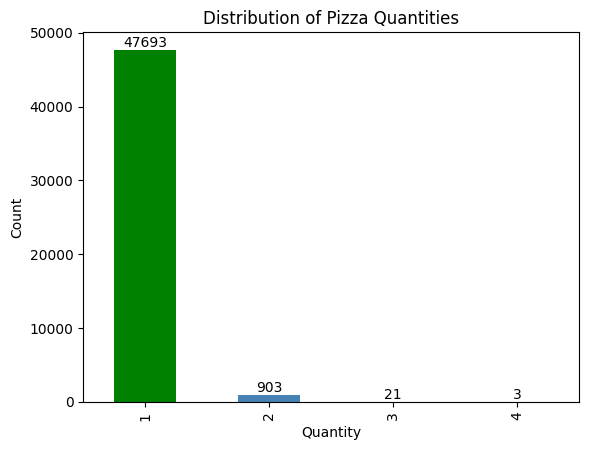

In [49]:
total_quantity = df['quantity'].value_counts()
best_count = total_quantity.idxmax()
worst_count = total_quantity.idxmin()
color_map = ['green' if count == best_count else 'red' if count == worst_count else 'steelblue' for count in total_quantity.index]
ax = total_quantity.plot(kind='bar', color=color_map)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.title('Distribution of Pizza Quantities')

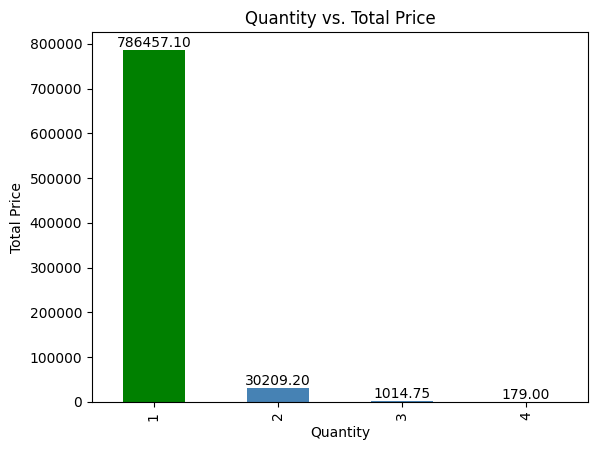

In [50]:
df['total_price']=df['quantity']*df['price']
summary = df.groupby('quantity')['total_price'].sum()
best_quantity = summary.idxmax()
worst_quantity = summary.idxmin()
color_map = ['green' if quantity == best_quantity else 'red' if quantity == worst_quantity else 'steelblue' for quantity in summary.index]
ax = summary.plot(kind='bar', color=color_map)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.xlabel('Quantity')
plt.ylabel('Total Price')
plt.title('Quantity vs. Total Price')
plt.show()

Text(0.5, 1.0, 'Distribution of Pizza Orders by Hour')

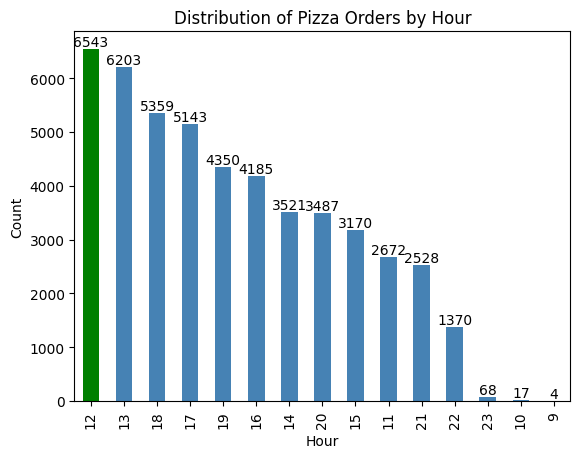

In [51]:
total_hour=df['hour'].value_counts()
rush_hour = total_hour.idxmax()
slow_hour = total_hour.idxmin()
color_map = ['green' if hour == rush_hour else 'red' if hour == slow_hour else 'steelblue' for hour in total_hour.index]
ax = total_hour.plot(kind='bar', color=color_map)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.title('Distribution of Pizza Orders by Hour')

Text(0.5, 1.0, 'Distribution of Pizza Orders by Day')

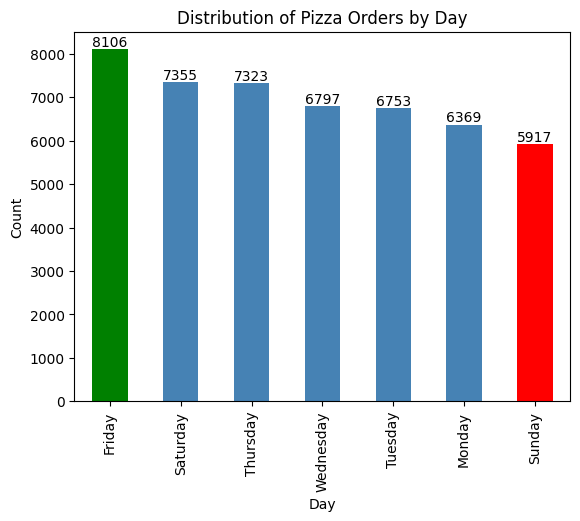

In [52]:
total_day = df['day_name'].value_counts()
busy_day_name = total_day.idxmax()
slow_day_name = total_day.idxmin()
color_map = ['green' if day == busy_day_name else 'red' if day == slow_day_name else 'steelblue' for day in total_day.index]
ax = total_day.plot(kind='bar', color=color_map)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Distribution of Pizza Orders by Day')

Text(0.5, 1.0, 'Distribution of Pizza Orders by Month')

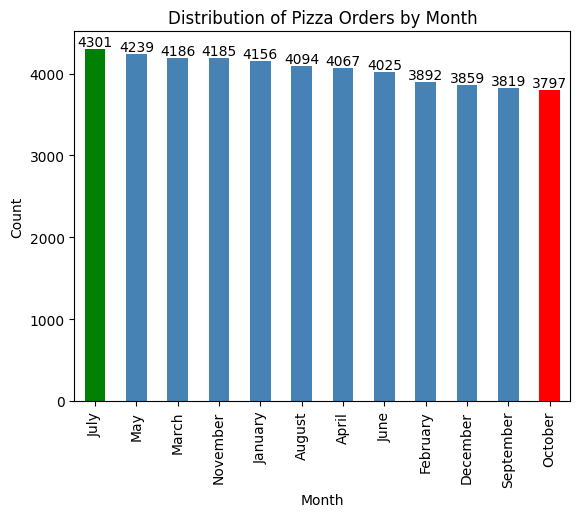

In [53]:
total_month = df['month'].value_counts()
busy_month = total_month.idxmax()
slow_month = total_month.idxmin()
color_map = ['green' if month == busy_month else 'red' if month == slow_month else 'steelblue' for month in total_month.index]
ax = total_month.plot(kind='bar', color=color_map)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Distribution of Pizza Orders by Month')

Text(0.5, 1.0, 'Distribution of Pizza Sizes')

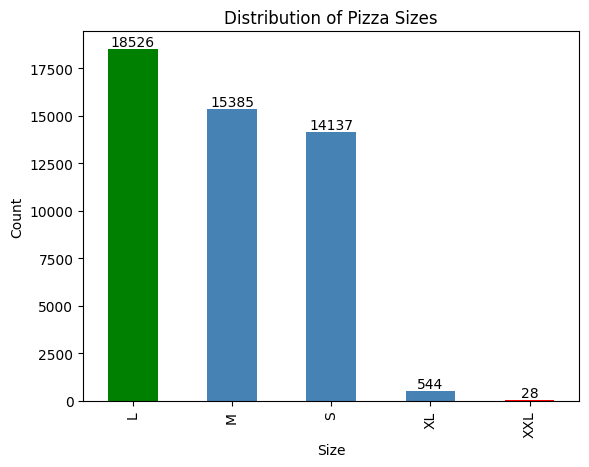

In [54]:
total_size = df['size'].value_counts()
favourite_size = total_size.idxmax()
worst_size = total_size.idxmin()
color_map = ['green' if size == favourite_size else 'red' if size == worst_size else 'steelblue' for size in total_size.index]
ax = total_size.plot(kind='bar', color=color_map)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.xlabel('Size')
plt.ylabel('Count') 
plt.title('Distribution of Pizza Sizes')

Text(0.5, 1.0, 'Distribution of Pizza Prices')

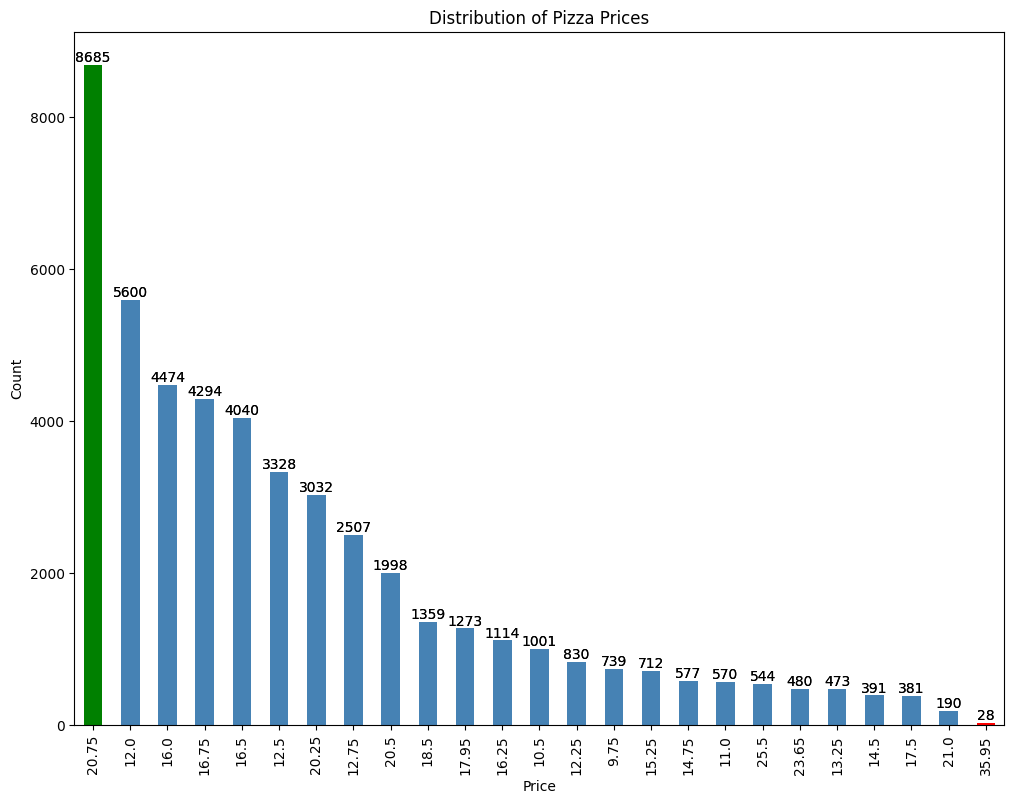

In [55]:
total_price = df['price'].value_counts()
ax = total_price.plot(kind='bar',figsize=(12, 9))
best_price = total_price.idxmax()
worst_price = total_price.idxmin()
color_map = ['green' if price == best_price else 'red' if price == worst_price else 'steelblue' for price in total_price.index]
ax = total_price.plot(kind='bar', figsize=(12, 9), color=color_map)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.xlabel('Price') 
plt.ylabel('Count')
plt.title('Distribution of Pizza Prices')

Text(0.5, 1.0, 'Distribution of Pizza Names')

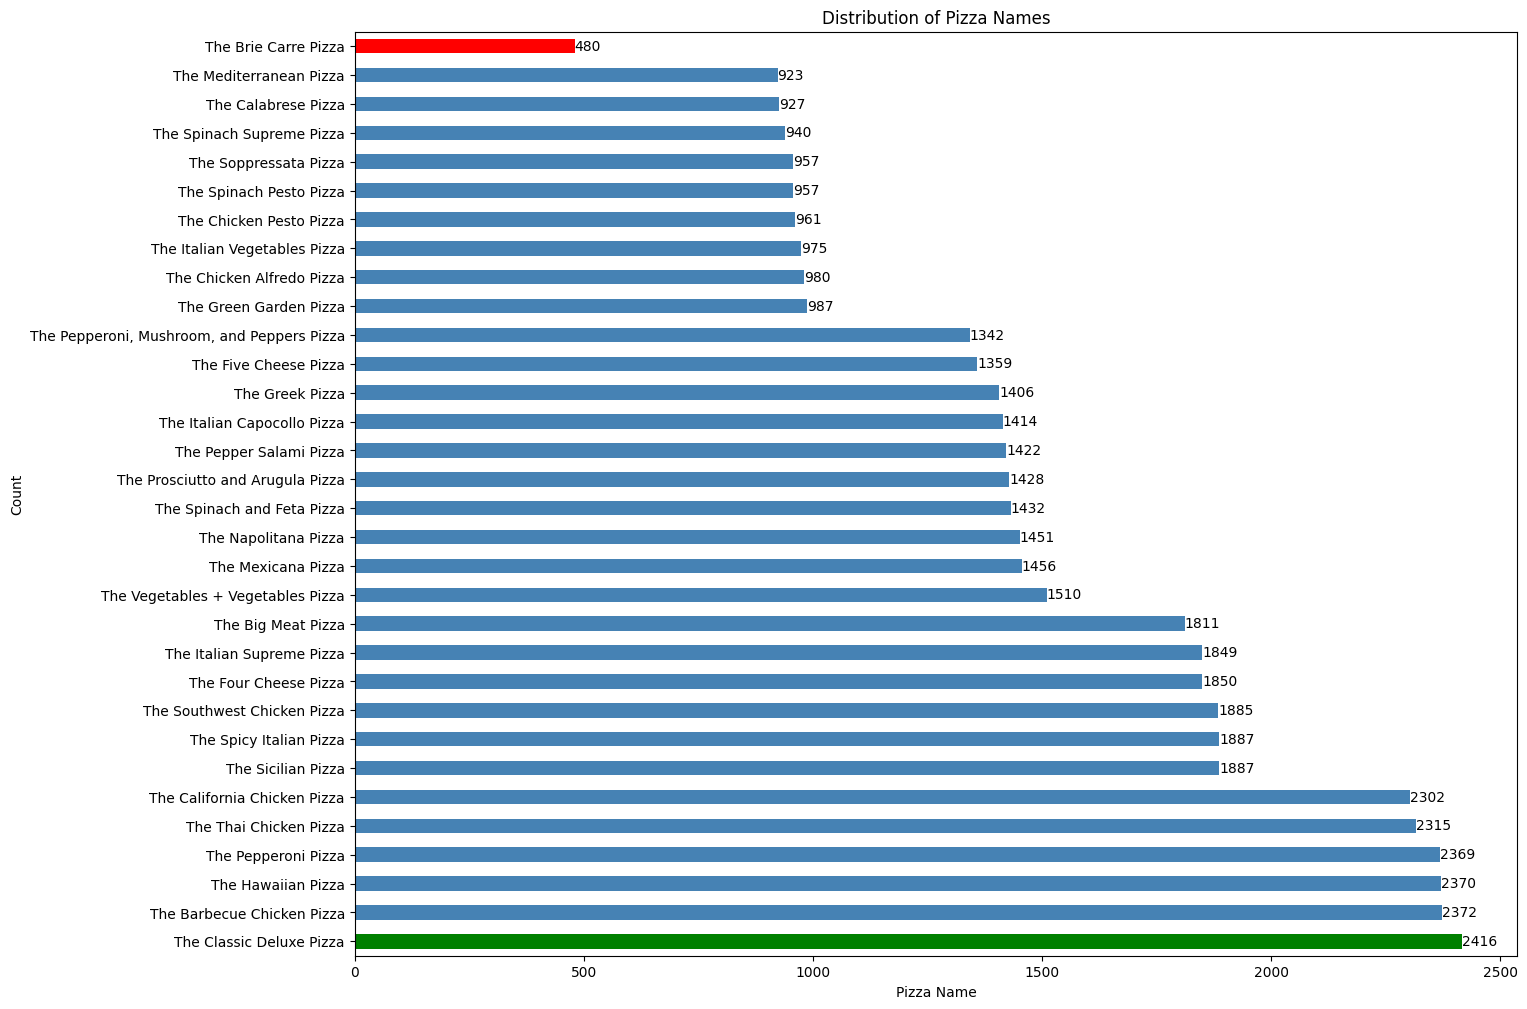

In [56]:
total_name = df['name'].value_counts()
best_name = total_name.idxmax()
worst_name = total_name.idxmin()
color_map = ['green' if name == best_name else 'red' if name == worst_name else 'steelblue' for name in total_name.index]
ax = total_name.plot(kind='barh',figsize=(15, 12), color=color_map)
for p in ax.patches:
    ax.annotate(f'{p.get_width()}', (p.get_width(), p.get_y() + p.get_height() / 2), ha='left', va='center')
plt.xlabel('Pizza Name')
plt.ylabel('Count')
plt.title('Distribution of Pizza Names')

Text(0.5, 1.0, 'Distribution of Pizza Categories')

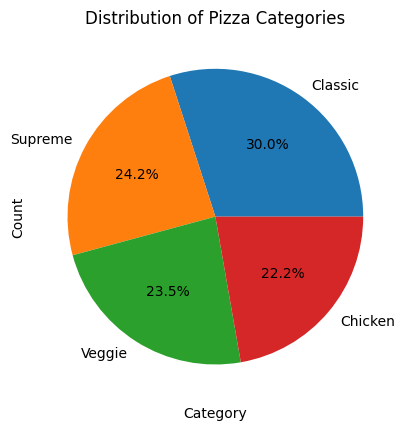

In [57]:
total_category = df['category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Distribution of Pizza Categories')